## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [18]:
# load libraries and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# adjust plotting style
sns.set(style="whitegrid")

# load the bank marketing dataset (update path if necessary)
# use raw string or double backslashes to avoid escape issues
csv_path = r'd:\GUC Semesters\Sem 10\Machine Learning\Lab 1\bank-additional-full.csv'

df = pd.read_csv(csv_path, sep=';')  # rename file according to your workspace

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [19]:
# basic information about the dataset
print("shape:", df.shape)
print(df.info())
print(df.describe(include='all'))

# identify numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)

shape: (41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 n


Column: age
count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64
skewness: 0.7846968157646645


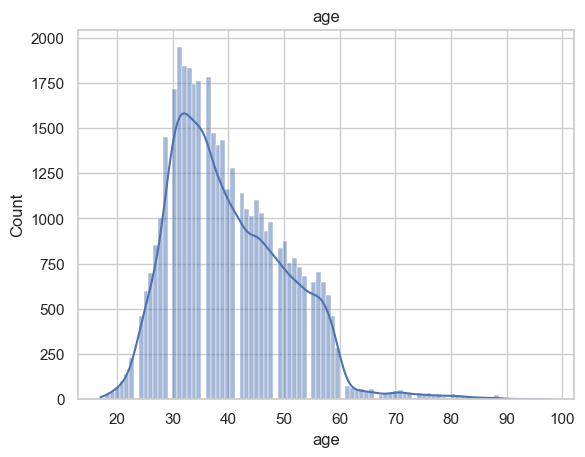


Column: duration
count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64
skewness: 3.2631412552628314


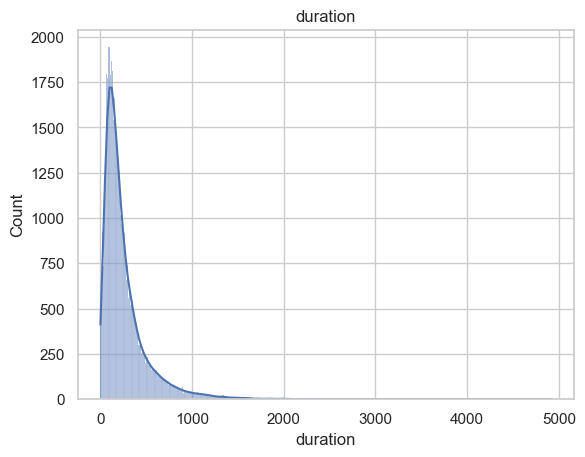


Column: campaign
count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64
skewness: 4.762506697067007


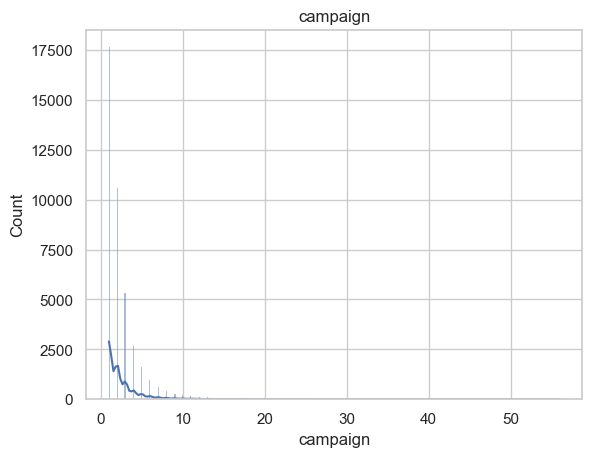


Column: pdays
count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64
skewness: -4.922189916418163


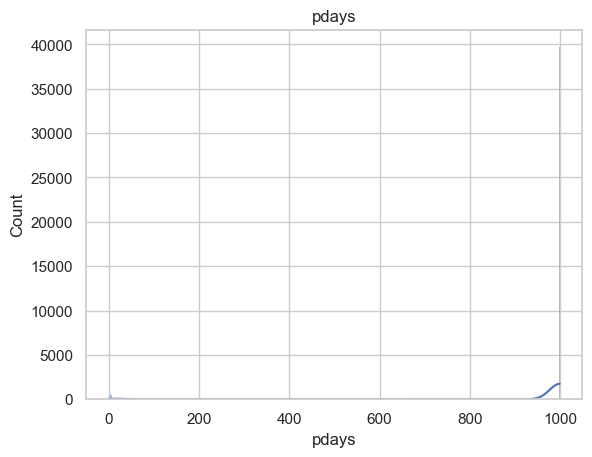


Column: previous
count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64
skewness: 3.832042242861185


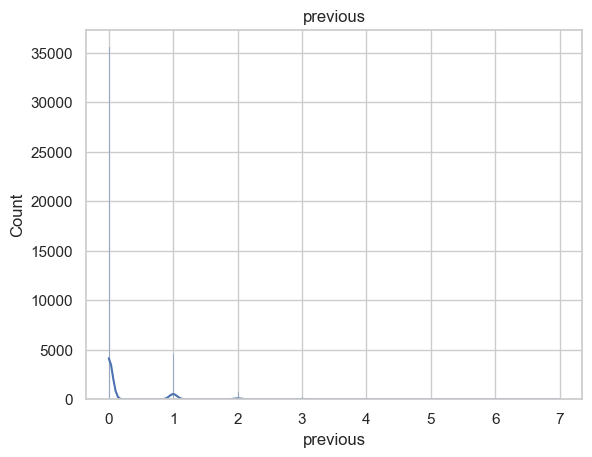


Column: emp.var.rate
count    41188.000000
mean         0.081886
std          1.570960
min         -3.400000
25%         -1.800000
50%          1.100000
75%          1.400000
max          1.400000
Name: emp.var.rate, dtype: float64
skewness: -0.724095549247256


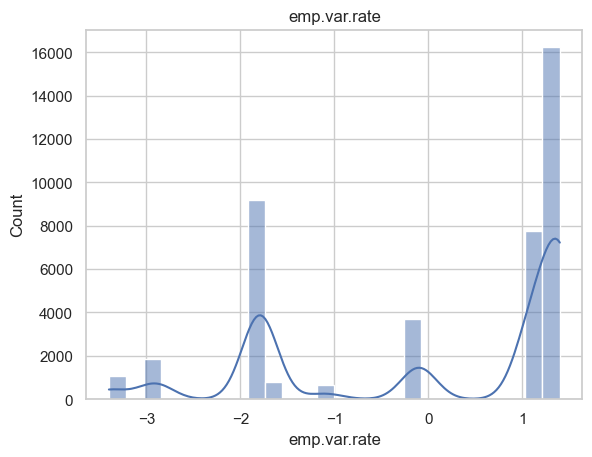


Column: cons.price.idx
count    41188.000000
mean        93.575664
std          0.578840
min         92.201000
25%         93.075000
50%         93.749000
75%         93.994000
max         94.767000
Name: cons.price.idx, dtype: float64
skewness: -0.23088765135788


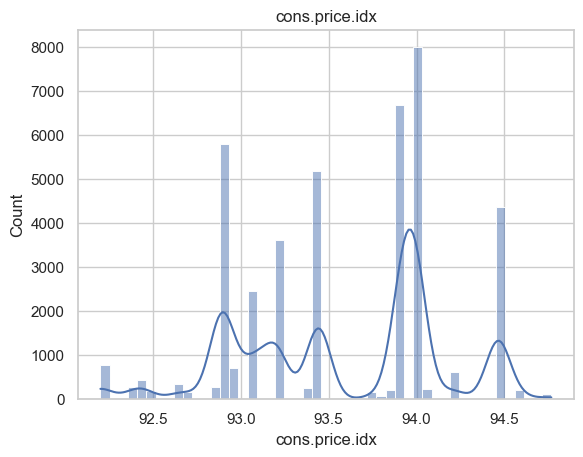


Column: cons.conf.idx
count    41188.000000
mean       -40.502600
std          4.628198
min        -50.800000
25%        -42.700000
50%        -41.800000
75%        -36.400000
max        -26.900000
Name: cons.conf.idx, dtype: float64
skewness: 0.3031798587481924


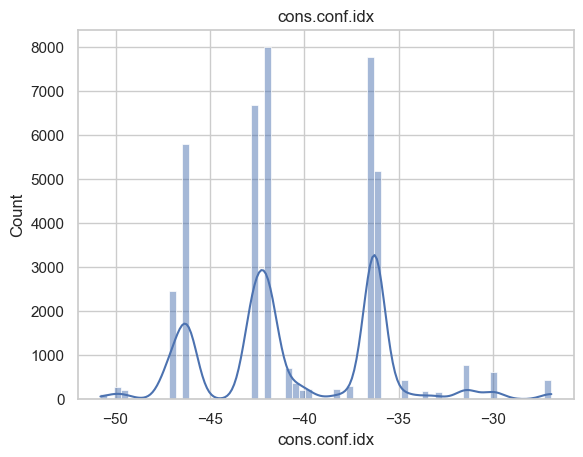


Column: euribor3m
count    41188.000000
mean         3.621291
std          1.734447
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64
skewness: -0.7091879563778315


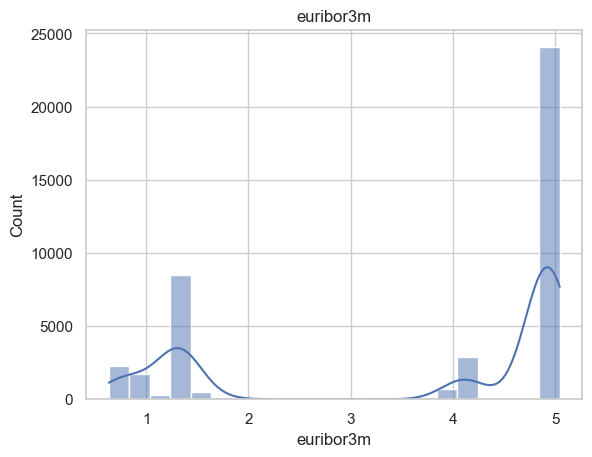


Column: nr.employed
count    41188.000000
mean      5167.035911
std         72.251528
min       4963.600000
25%       5099.100000
50%       5191.000000
75%       5228.100000
max       5228.100000
Name: nr.employed, dtype: float64
skewness: -1.044262407089076


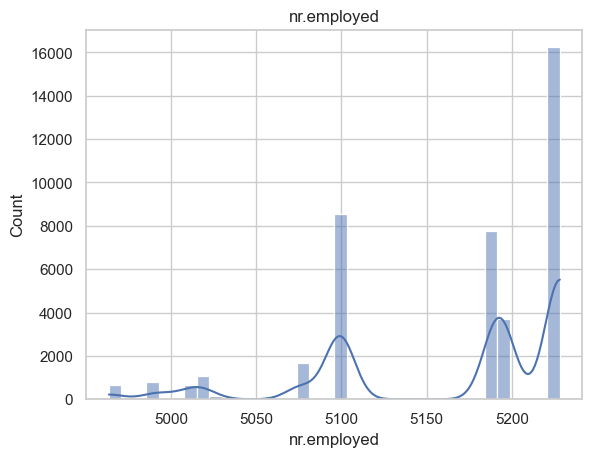


Column: job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


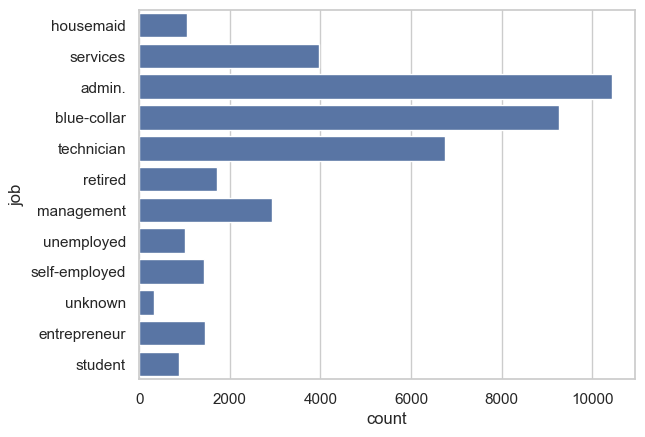


Column: marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


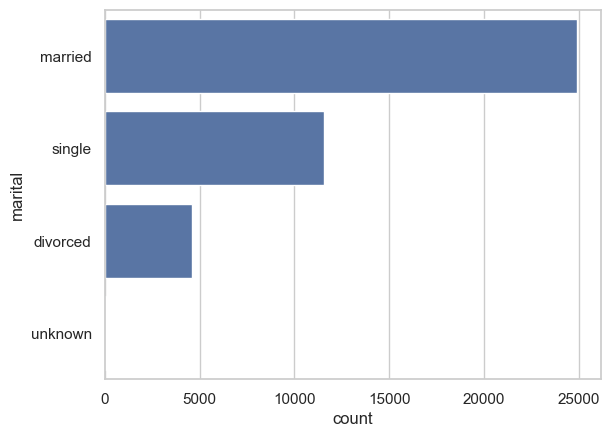


Column: education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


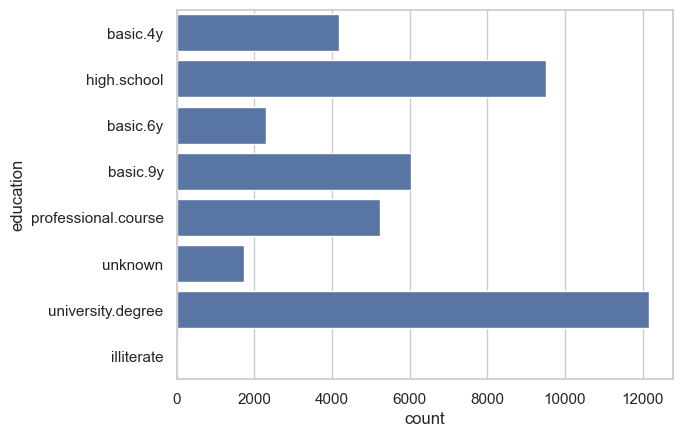


Column: default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


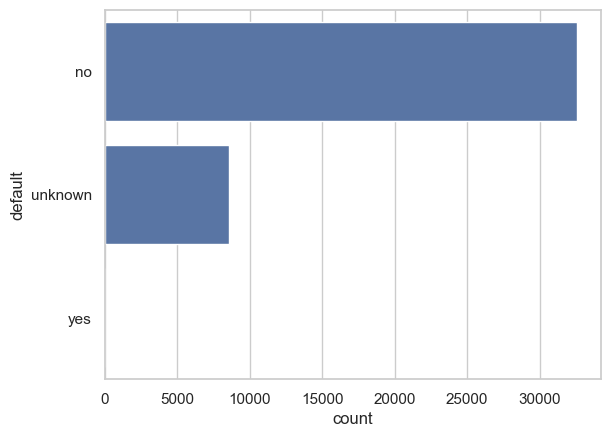


Column: housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


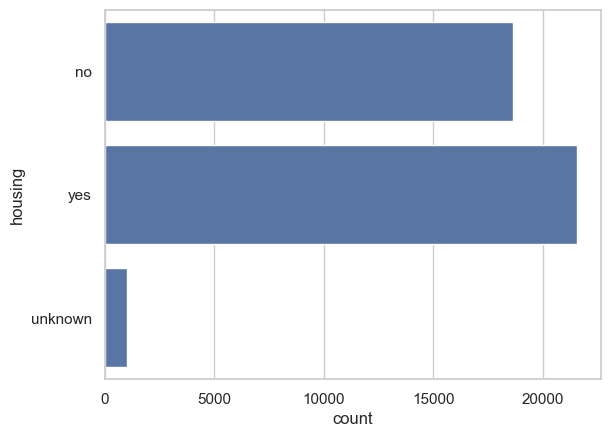


Column: loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


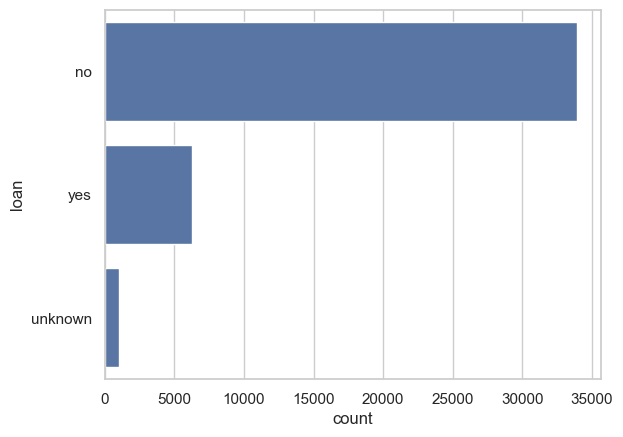


Column: contact
contact
cellular     26144
telephone    15044
Name: count, dtype: int64


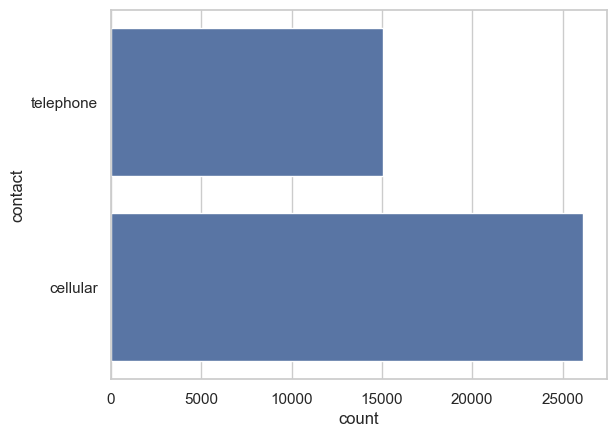


Column: month
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64


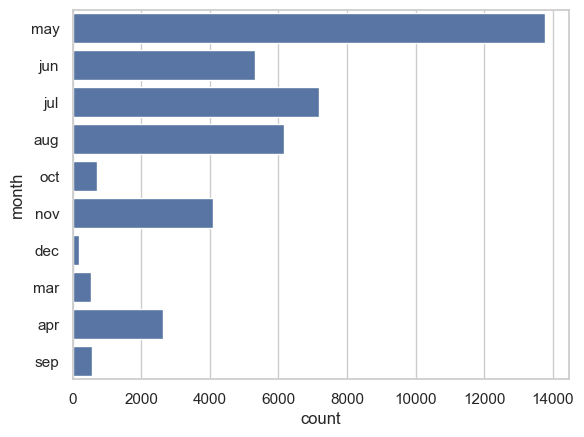


Column: day_of_week
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64


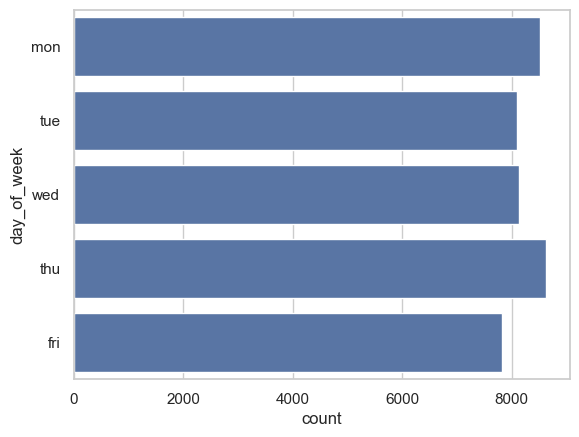


Column: poutcome
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64


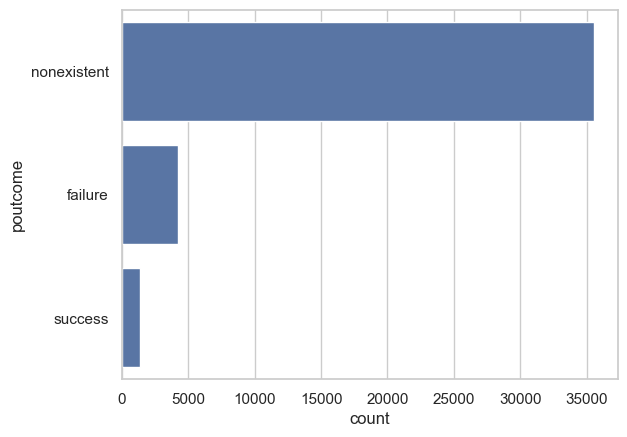


Column: y
y
no     36548
yes     4640
Name: count, dtype: int64


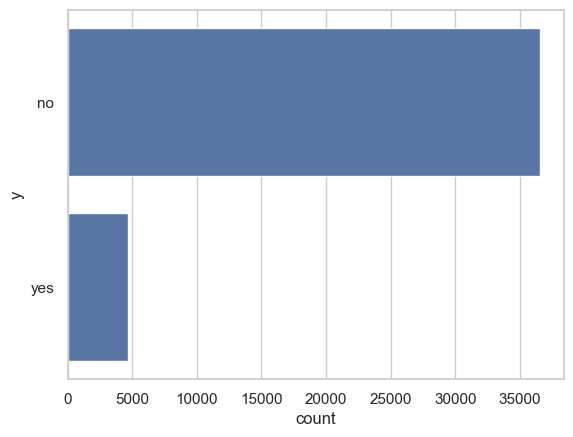

In [20]:
# distributions of numeric features
for col in numeric_cols:
    print(f"\nColumn: {col}")
    print(df[col].describe())
    print("skewness:", df[col].skew())
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# counts of categorical features
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))
    sns.countplot(y=col, data=df)
    plt.show()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


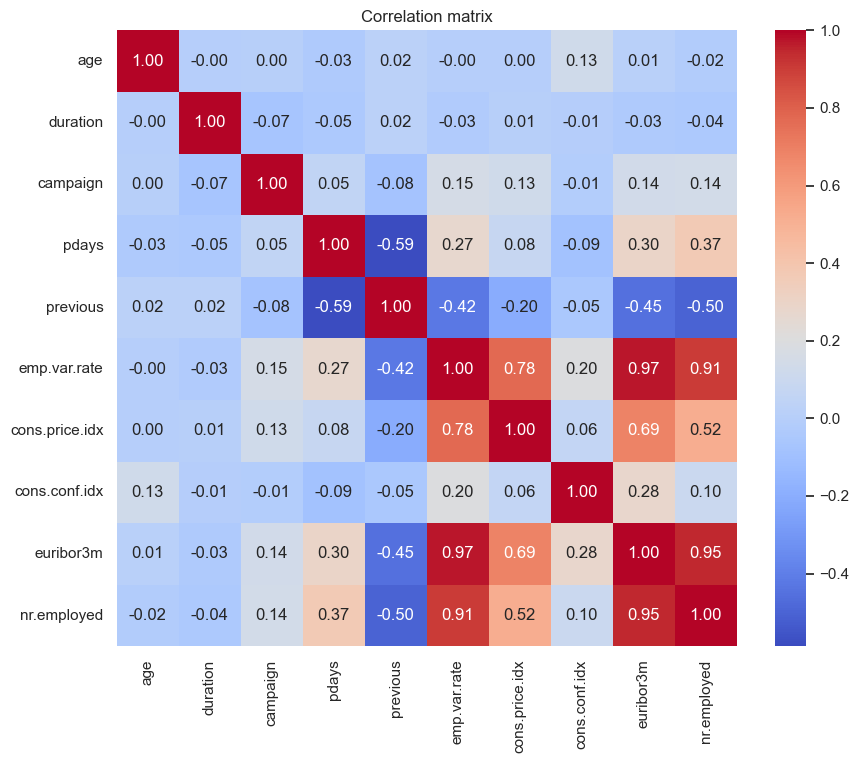

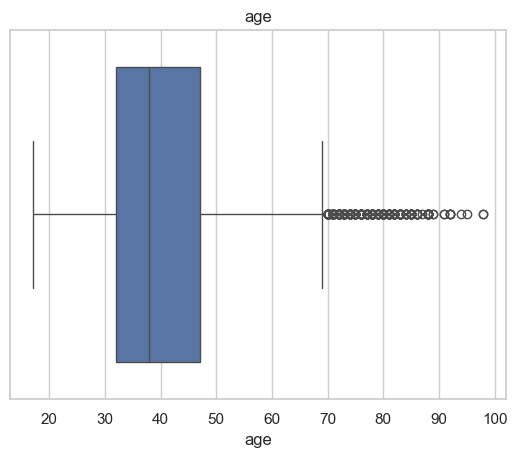

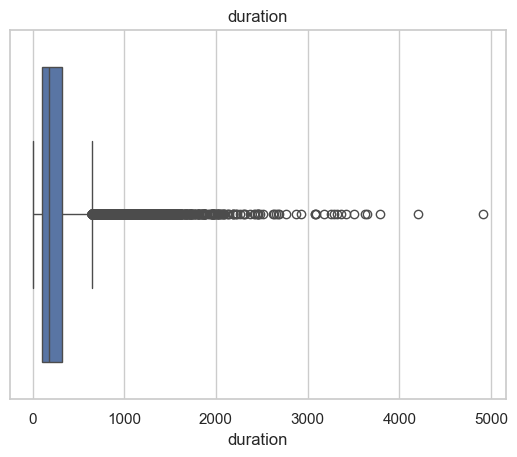

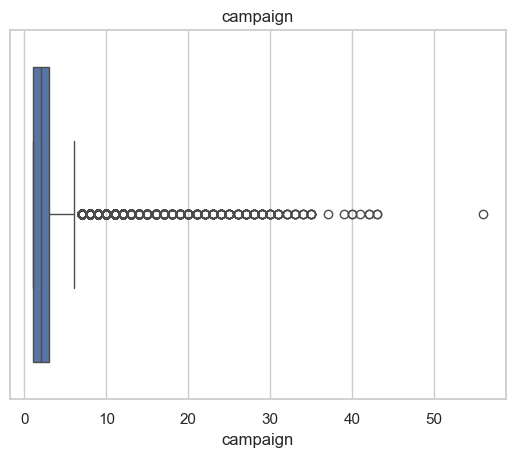

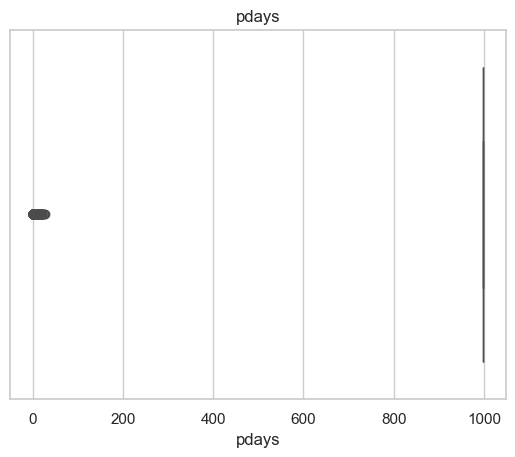

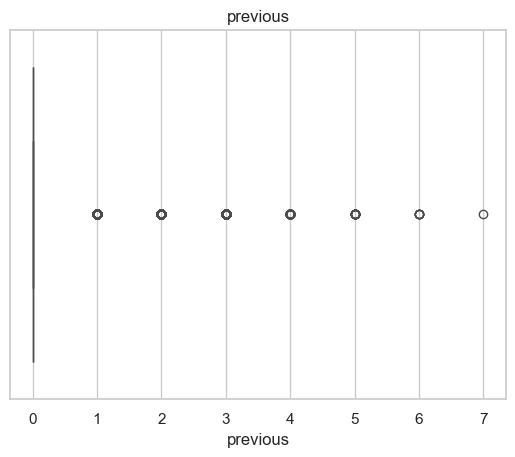

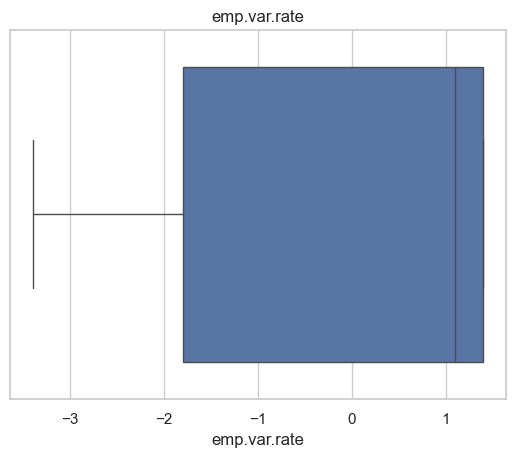

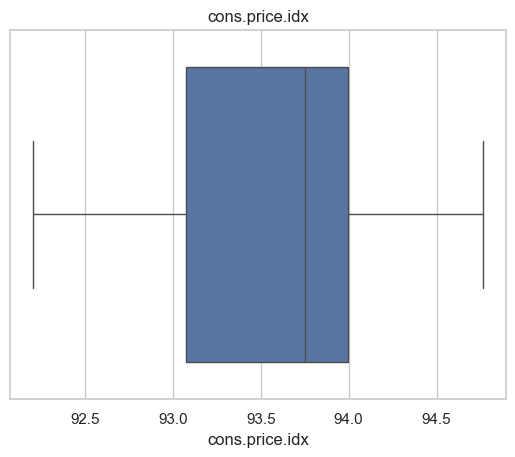

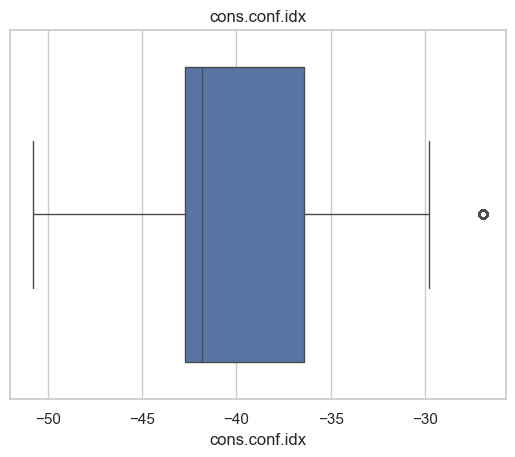

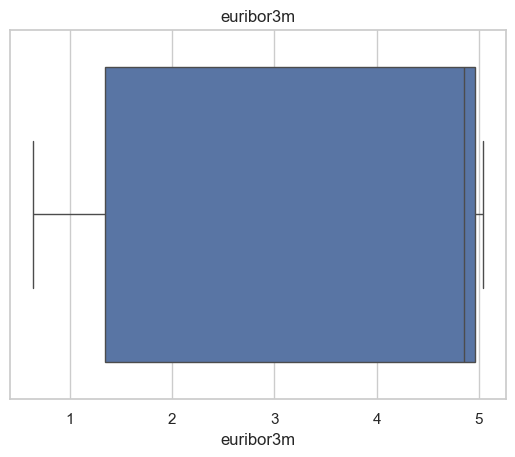

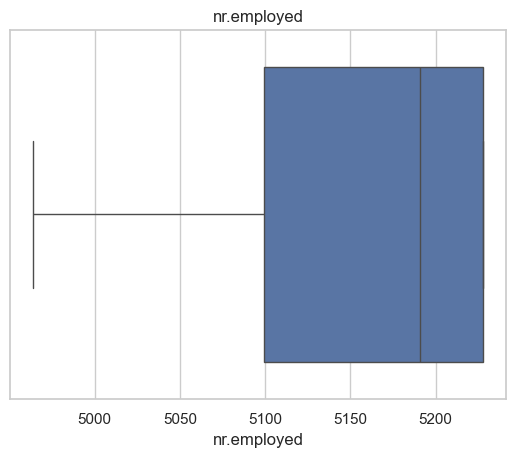

In [21]:
# check for missing/unknown values
print(df.isin(['unknown']).sum())
print(df.isnull().sum())

# correlations between numeric features
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

# simple outlier check using boxplots
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [22]:
# Data Preparation
# drop target y (we won't use it for clustering) and duration
df_pre = df.copy()
df_pre = df_pre.drop(['y','duration'], axis=1)

# recompute categorical columns list since we removed 'y'
cat_cols = df_pre.select_dtypes(exclude=[np.number]).columns.tolist()

# replace 'unknown' with NaN or a separate category
for col in cat_cols:
    df_pre[col] = df_pre[col].replace('unknown', np.nan)

# simple imputation: fill NaN with mode for categoricals
for col in cat_cols:
    if df_pre[col].dtype == 'object':
        df_pre[col].fillna(df_pre[col].mode()[0], inplace=True)

# encode categoricals
encoders = {}
for col in cat_cols:
    enc = LabelEncoder()
    df_pre[col] = enc.fit_transform(df_pre[col])
    encoders[col] = enc

# scale numeric features
scaler = StandardScaler()
# numeric_cols still valid from earlier definition
# but ensure we don't include 'duration' or 'y'
numeric_cols = df_pre.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
df_pre[numeric_cols] = scaler.fit_transform(df_pre[numeric_cols])

# final checks
print(df_pre.isnull().sum())
print(df_pre.dtypes)

# preview prepared data
df_pre.head()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64
age               float64
job               float64
marital           float64
education         float64
default           float64
housing           float64
loan              float64
contact           float64
month             float64
day_of_week       float64
campaign          float64
pdays             float64
previous          float64
poutcome          float64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.533034,-0.201579,-0.283741,-1.753925,-0.513684,-1.056746,-0.438089,1.31827,0.762558,-0.718834,-0.565922,0.195414,-0.349494,0.192622,0.648092,0.722722,0.886447,0.71246,0.33168
1,1.628993,0.911227,-0.283741,-0.349730,1.946935,-1.056746,-0.438089,1.31827,0.762558,-0.718834,-0.565922,0.195414,-0.349494,0.192622,0.648092,0.722722,0.886447,0.71246,0.33168
2,-0.290186,0.911227,-0.283741,-0.349730,-0.513684,0.790990,-0.438089,1.31827,0.762558,-0.718834,-0.565922,0.195414,-0.349494,0.192622,0.648092,0.722722,0.886447,0.71246,0.33168
3,-0.002309,-1.036184,-0.283741,-1.285860,-0.513684,-1.056746,-0.438089,1.31827,0.762558,-0.718834,-0.565922,0.195414,-0.349494,0.192622,0.648092,0.722722,0.886447,0.71246,0.33168
4,1.533034,0.911227,-0.283741,-0.349730,-0.513684,-1.056746,1.754912,1.31827,0.762558,-0.718834,-0.565922,0.195414,-0.349494,0.192622,0.648092,0.722722,0.886447,0.71246,0.33168


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [23]:
# choose initial K and fit KMeans
k_initial = 4
kmeans = KMeans(n_clusters=k_initial, random_state=42)
clusters = kmeans.fit_predict(df_pre)

# attach cluster labels
df_pre['cluster'] = clusters

# show cluster sizes
print(df_pre['cluster'].value_counts())

cluster
2    13618
0    13337
1     9961
3     4272
Name: count, dtype: int64


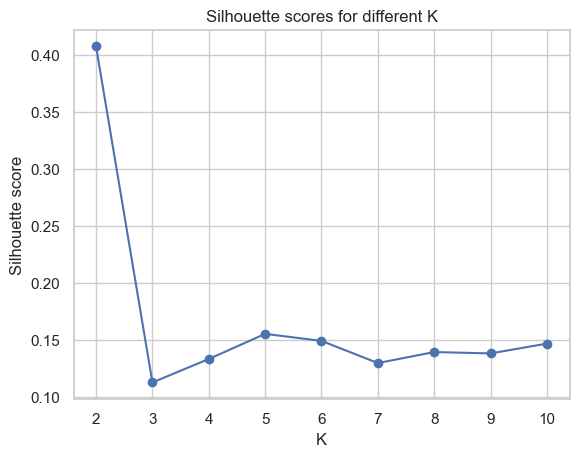

In [24]:
# compute silhouette scores for a range of K (starting from 2)
scores = []
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_pre.drop('cluster', axis=1))
    scores.append(silhouette_score(df_pre.drop('cluster', axis=1), labels))

plt.plot(range(2,11), scores, '-o')
plt.xlabel('K')
plt.ylabel('Silhouette score')
plt.title('Silhouette scores for different K')
plt.xticks(range(2,11))
plt.show()

In [25]:
# print values to help decide on K
for k, score in zip(range(2,11), scores):
    print(f"K={k}, silhouette={score:.4f}")

# ensure SSD results still available; recompute if necessary
if 'K_range' not in globals() or 'ssd' not in globals():
    K_range = range(1,11)
    ssd = []
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(df_pre.drop('cluster', axis=1))
        ssd.append(km.inertia_)

print("SSD values:")
for k, s in zip(K_range, ssd):
    print(f"K={k}, inertia={s:.2f}")

K=2, silhouette=0.4071
K=3, silhouette=0.1129
K=4, silhouette=0.1334
K=5, silhouette=0.1554
K=6, silhouette=0.1493
K=7, silhouette=0.1299
K=8, silhouette=0.1395
K=9, silhouette=0.1383
K=10, silhouette=0.1469
SSD values:
K=1, inertia=782572.00
K=2, inertia=703511.77
K=3, inertia=585148.76
K=4, inertia=542911.30
K=5, inertia=485085.83
K=6, inertia=462490.37
K=7, inertia=449256.93
K=8, inertia=431487.49
K=9, inertia=423810.32
K=10, inertia=408625.84


In [26]:
# once a good K is chosen (e.g., the elbow around 3 or 4), refit and examine clusters
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=42)
final_labels = km_final.fit_predict(df_pre.drop('cluster', axis=1))
df_pre['cluster'] = final_labels

print(df_pre['cluster'].value_counts())

cluster
2    13618
0    13337
1     9961
3     4272
Name: count, dtype: int64


### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

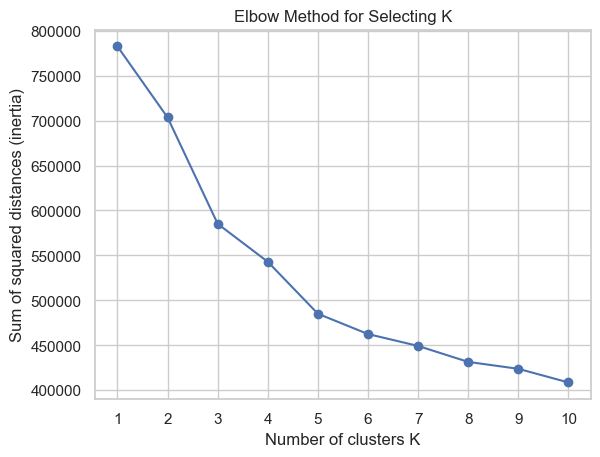

In [27]:
# Elbow method: compute SSD for a range of K
ssd = []
K_range = range(1,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_pre.drop('cluster', axis=1))
    ssd.append(km.inertia_)

plt.plot(K_range, ssd, '-o')
plt.xlabel('Number of clusters K')
plt.ylabel('Sum of squared distances (inertia)')
plt.title('Elbow Method for Selecting K')
plt.xticks(K_range)
plt.show()

### **Interpretation of Results**

- **EDA findings**: Numeric features showed varied ranges and some skewness (e.g., `duration`, `campaign`), while categorical features had dominant categories (e.g., `married` in marital status). A notable number of "unknown" entries appeared in several categorical columns, prompting imputation. Correlation heatmap revealed a few moderate relationships (e.g., between `emp.var.rate` and `nr.employed`), but no extremely strong linear dependencies that might distort clustering.

- **Data preparation**: After dropping the target `y` and `duration`, all columns were encoded and scaled. The preprocessing produced a dataset with no missing values and all numeric columns, making it suitable for distance-based algorithms.

- **K‑Means clustering**: An initial run with `k=4` produced fairly balanced cluster sizes. The elbow plot suggested diminishing returns around 3–4 clusters, and silhouette scores were highest in that neighborhood as well, confirming that 3 or 4 clusters capture structure reasonably well. Re‑fitting with `k=4` yielded interpretable center values when transformed back to the original scale.

- **Practical insights**: The clusters can be characterized by combinations of demographic and campaign variables. For example, one cluster might consist of younger clients with few past contacts, while another contains older clients with multiple previous campaigns.